In [1]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]
CAT_COLS = ["Month", "OperatingSystems", "Browser", "Region",
            "TrafficType", "VisitorType", "Weekend"]

y = shoppers["Revenue"].astype(int)

print(f"수치형 {len(NUM_COLS)}개 · 범주형 {len(CAT_COLS)}개 · 타깃 1개")
print("범주별 값 개수:", {c: shoppers[c].nunique() for c in CAT_COLS})
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
수치형 10개 · 범주형 7개 · 타깃 1개
범주별 값 개수: {'Month': 10, 'OperatingSystems': 8, 'Browser': 13, 'Region': 9, 'TrafficType': 20, 'VisitorType': 3, 'Weekend': 2}

→ 준비 완료. 이제 여러분 차례입니다.


In [3]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 오늘 쓰는 도구 — 전처리·조립·검증
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV, cross_validate)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   OneHotEncoder, OrdinalEncoder, TargetEncoder)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료!")
import sklearn
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

환경 준비 완료!
- scikit-learn 1.9.0
- 그래프 한글 폰트: Malgun Gothic


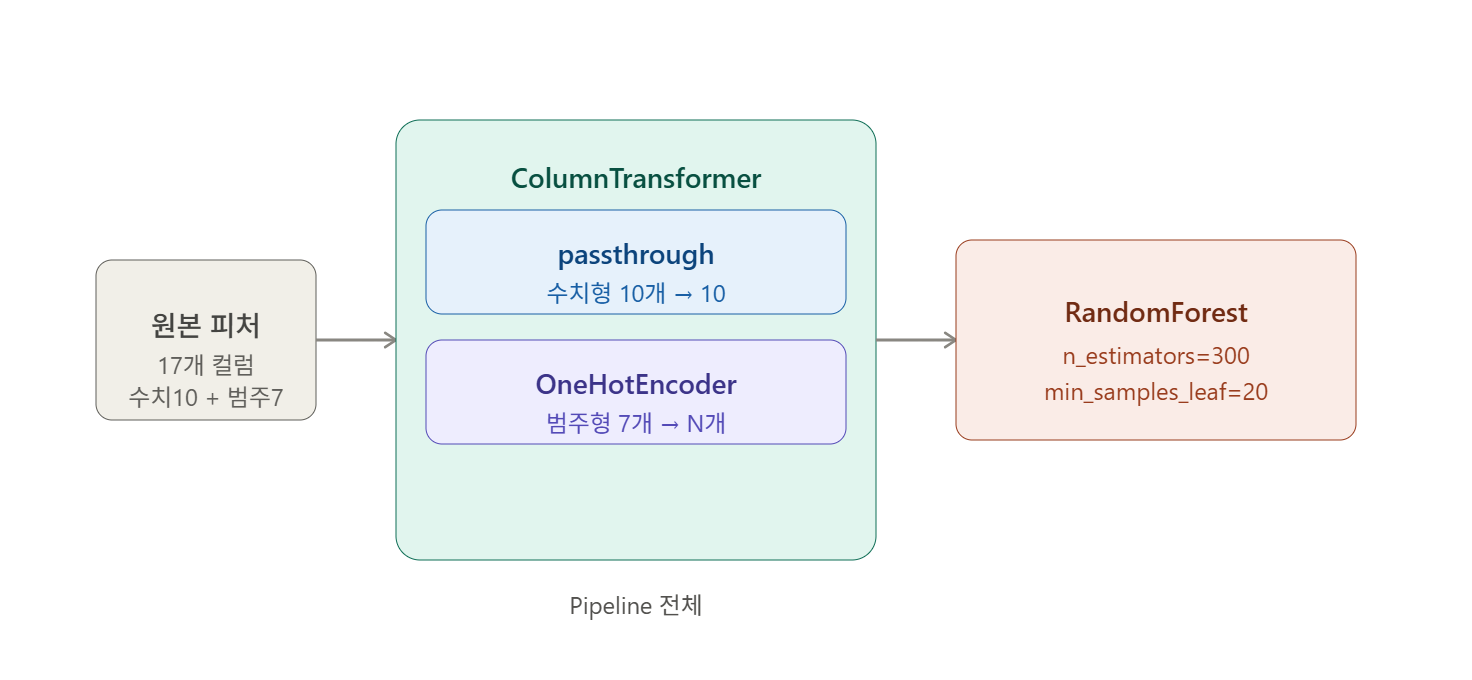

In [4]:
# ─────────────────────────────────────────────
# [C2] 파이프라인 구성 + 5겹 CV 비교
# ─────────────────────────────────────────────

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── 1) ColumnTransformer 구성 ──────────────────
ct = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM_COLS),          # 수치형: 그대로
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False                    # sklearn ≥1.2; 구버전은 sparse=False 행렬타입충돌방지
        ), CAT_COLS),                              # 범주형: OHE
    ]
)

# ── 2) Pipeline 구성 ──────────────────────────
rf_full = Pipeline([
    ("preprocess", ct),
    ("model",      RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1                               #병렬 처리
    )),
])

# ── 비교 기준: 수치형 10개만 쓰는 파이프라인 ──
rf_num = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", NUM_COLS)
    ])),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

# ── 3) 5겹 CV 실행 ────────────────────────────
SCORING = ["f1", "average_precision"]
X = shoppers[NUM_COLS + CAT_COLS]

print("▶ [수치형만] CV 중...")
res_num  = cross_validate(rf_num,  X, y, cv=cv, scoring=SCORING)

print("▶ [수치형+범주형] CV 중...")
res_full = cross_validate(rf_full, X, y, cv=cv, scoring=SCORING)

# ── 4) 변환 후 피처 수 확인 ───────────────────
ct.fit(X)                       # fit 해야 get_feature_names_out() 사용 가능
n_features = ct.transform(X).shape[1]

# ── 결과 출력 ──────────────────────────────────
import pandas as pd
result = pd.DataFrame({
    "모델"         : ["수치형 10개만", "수치형+범주형(OHE)"],
    "F1 (mean)"    : [res_num ["test_f1"].mean(),
                      res_full["test_f1"].mean()],
    "F1 (std)"     : [res_num ["test_f1"].std(),
                      res_full["test_f1"].std()],
    "AP (mean)"    : [res_num ["test_average_precision"].mean(),
                      res_full["test_average_precision"].mean()],
    "AP (std)"     : [res_num ["test_average_precision"].std(),
                      res_full["test_average_precision"].std()],
}).set_index("모델")

print(result.round(4).to_string())
print(f"\n✅ 변환 후 총 피처 수: {n_features}개")
print(f"   (수치형 {len(NUM_COLS)}개 + OHE 팽창 {n_features - len(NUM_COLS)}개)")

▶ [수치형만] CV 중...
▶ [수치형+범주형] CV 중...
              F1 (mean)  F1 (std)  AP (mean)  AP (std)
모델                                                    
수치형 10개만         0.6186    0.0175     0.7248    0.0191
수치형+범주형(OHE)     0.5764    0.0253     0.7371    0.0158

✅ 변환 후 총 피처 수: 66개
   (수치형 10개 + OHE 팽창 56개)


In [5]:
# ─────────────────────────────────────────────
# [C3] 피처 엔지니어링 가설 검증
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["f1", "average_precision"]

# ── 피처 엔지니어링 함수 정의 ─────────────────
def add_has_page_value(X):
    """가설 A: PageValues > 0 이면 1, 아니면 0"""
    X = X.copy()
    X["has_page_value"] = (X["PageValues"] > 0).astype(int)
    return X

def add_total_pages(X):
    """가설 B: 세 페이지 유형의 합산"""
    X = X.copy()
    X["total_pages"] = (
        X["Administrative"] + X["Informational"] + X["ProductRelated"]
    )
    return X

# ── 파이프라인 생성 함수 (반복 방지) ──────────
def make_pipeline(extra_num_cols=None, fe_func=None):
    """
    fe_func  : 피처 엔지니어링 함수 (없으면 None)
    extra_num_cols : 새로 추가되는 수치형 컬럼명 리스트
    """
    num_cols = NUM_COLS + (extra_num_cols or [])

    ct = ColumnTransformer([
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False
        ), CAT_COLS),
    ])

    steps = []
    if fe_func:
        steps.append(("fe", FunctionTransformer(fe_func)))
    steps.append(("preprocess", ct))
    steps.append(("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )))

    return Pipeline(steps)

# ── CV 실행 ───────────────────────────────────
X = shoppers[NUM_COLS + CAT_COLS]

print("▶ [베이스라인] CV 중...")
res_base = cross_validate(
    make_pipeline(), X, y, cv=cv, scoring=SCORING
)

print("▶ [가설 A: has_page_value] CV 중...")
res_A = cross_validate(
    make_pipeline(
        extra_num_cols=["has_page_value"],
        fe_func=add_has_page_value
    ),
    X, y, cv=cv, scoring=SCORING
)

print("▶ [가설 B: total_pages] CV 중...")
res_B = cross_validate(
    make_pipeline(
        extra_num_cols=["total_pages"],
        fe_func=add_total_pages
    ),
    X, y, cv=cv, scoring=SCORING
)

# ── 결과 정리 ─────────────────────────────────
def mean_std(res, key):
    return res[f"test_{key}"].mean(), res[f"test_{key}"].std()

base_f1, base_f1_std = mean_std(res_base, "f1")
base_ap, base_ap_std = mean_std(res_base, "average_precision")

rows = []
for label, res in [("베이스라인",     res_base),
                   ("+ 가설 A (has_page_value)", res_A),
                   ("+ 가설 B (total_pages)",     res_B)]:
    f1, f1s = mean_std(res, "f1")
    ap, aps = mean_std(res, "average_precision")
    rows.append({
        "모델":       label,
        "F1":         f1,
        "F1 std":     f1s,
        "ΔF1":        f1 - base_f1,
        "AP":         ap,
        "AP std":     aps,
        "ΔAP":        ap - base_ap,
    })

result = pd.DataFrame(rows).set_index("모델")
print("\n" + result.round(4).to_string())

# ── 채택·기각 판정 ─────────────────────────────
THRESHOLD = 0.001   # ΔF1 또는 ΔAP 중 하나라도 0.1%p 이상이면 채택

for label, res in [("가설 A", res_A), ("가설 B", res_B)]:
    dF1 = mean_std(res, "f1")[0]             - base_f1
    dAP = mean_std(res, "average_precision")[0] - base_ap
    adopt = dF1 > THRESHOLD or dAP > THRESHOLD
    verdict = "✅ 채택" if adopt else "❌ 기각"
    print(f"{verdict}  {label}  |  ΔF1={dF1:+.4f}  ΔAP={dAP:+.4f}")

▶ [베이스라인] CV 중...
▶ [가설 A: has_page_value] CV 중...
▶ [가설 B: total_pages] CV 중...

                             F1  F1 std     ΔF1      AP  AP std     ΔAP
모델                                                                     
베이스라인                    0.5764  0.0253  0.0000  0.7371  0.0158  0.0000
+ 가설 A (has_page_value)  0.6465  0.0211  0.0701  0.7498  0.0132  0.0127
+ 가설 B (total_pages)     0.5797  0.0256  0.0033  0.7399  0.0147  0.0027
✅ 채택  가설 A  |  ΔF1=+0.0701  ΔAP=+0.0127
✅ 채택  가설 B  |  ΔF1=+0.0033  ΔAP=+0.0027


결과 해석
- 가설 A: 압도적 채택 = `pageValues`가 0인 사람과 아닌 사람 사이에 구매여부가 질적으로 달랐다.
- 가설 B: 효과가 있긴 하지만 미미함, 이미 세 컬럼이 개별적으로 모델이 들어가 있기 때문

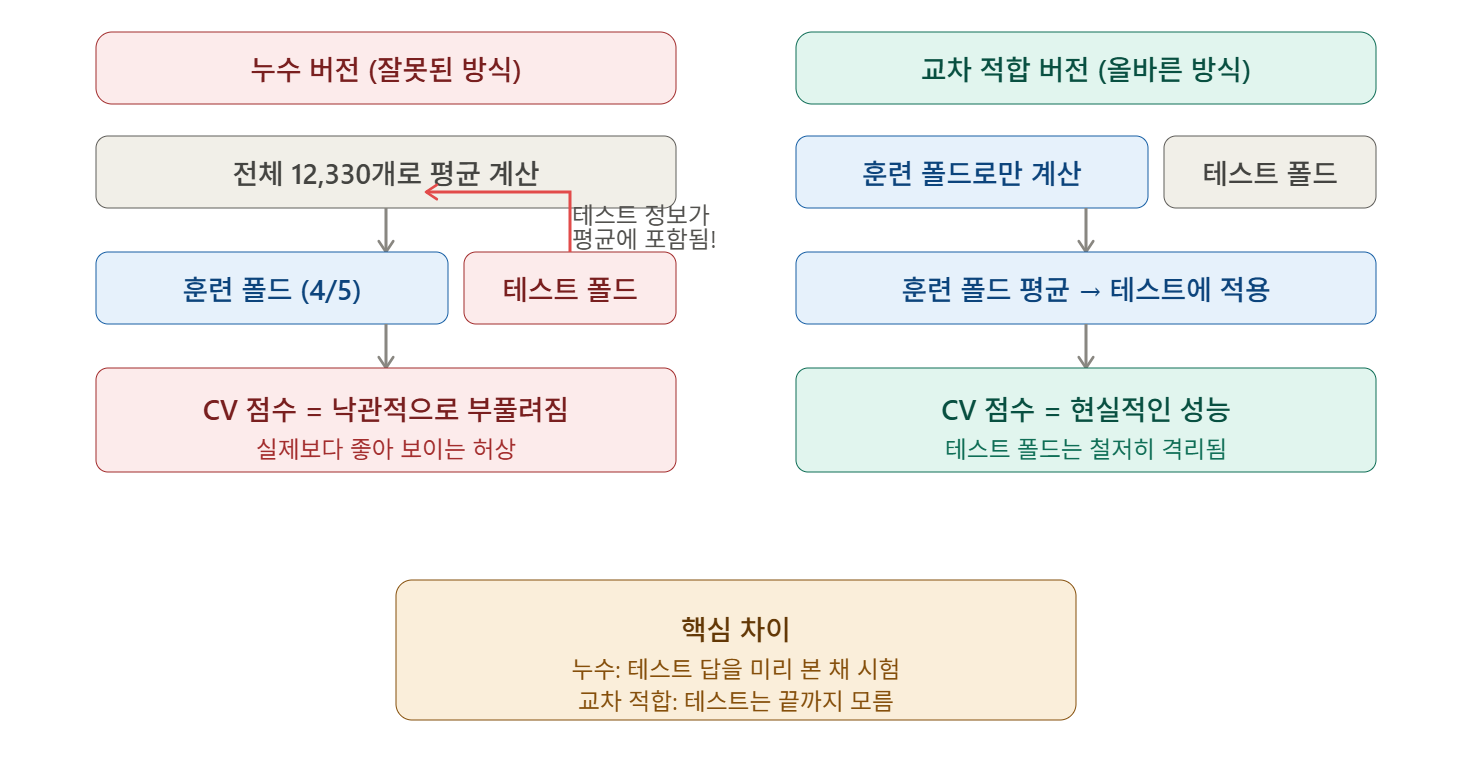

In [10]:
!pip install category_encoders

In [11]:
# ─────────────────────────────────────────────
# [C4] 조합 피처 + 누수 vs 교차 적합 비교
# ─────────────────────────────────────────────

from category_encoders import TargetEncoder   # pip install category_encoders

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["f1", "average_precision"]

# ── 1) 조합 키 탐색 ───────────────────────────
shoppers["combo"] = (
    shoppers["Month"].astype(str) + "_" +
    shoppers["TrafficType"].astype(str) + "_" +
    shoppers["Region"].astype(str)
)

n_combos   = shoppers["combo"].nunique()
combo_cnt  = shoppers["combo"].value_counts()
n_rare     = (combo_cnt < 10).sum()

print(f"총 조합 수       : {n_combos}개")
print(f"10건 미만 조합   : {n_rare}개")
print(f"전체 조합 중 희소 비율: {n_rare/n_combos:.1%}")
print()

# ── 2) 누수 버전 ──────────────────────────────
# 전체 데이터로 조합별 Revenue 평균을 미리 계산
combo_mean = shoppers.groupby("combo")["Revenue"].mean()
shoppers["combo_revenue_LEAK"] = shoppers["combo"].map(combo_mean)

# 누수 피처를 포함한 수치형 컬럼 리스트
NUM_LEAK = NUM_COLS + ["combo_revenue_LEAK"]

pipe_leak = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", NUM_LEAK),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False
        ), CAT_COLS),
    ])),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

X_leak = shoppers[NUM_LEAK + CAT_COLS]
print("▶ [누수 버전] CV 중...")
res_leak = cross_validate(pipe_leak, X_leak, y, cv=cv, scoring=SCORING)

# ── 3) 교차 적합 버전 (TargetEncoder in Pipeline) ──
# combo 컬럼을 범주형으로 보고 Pipeline 안에서 인코딩
X_te = shoppers[NUM_COLS + CAT_COLS + ["combo"]]

pipe_te = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", NUM_COLS),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False
        ), CAT_COLS),
        ("te", TargetEncoder(smoothing=5), ["combo"]),  # 교차 적합 자동 수행
    ])),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

print("▶ [교차 적합 버전] CV 중...")
res_te = cross_validate(pipe_te, X_te, y, cv=cv, scoring=SCORING)

# ── 4) 베이스라인 재사용 (문제 1의 ②) ─────────
X_base = shoppers[NUM_COLS + CAT_COLS]
pipe_base = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", "passthrough", NUM_COLS),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=False
        ), CAT_COLS),
    ])),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])
print("▶ [베이스라인] CV 중...")
res_base = cross_validate(pipe_base, X_base, y, cv=cv, scoring=SCORING)

# ── 결과 정리 ─────────────────────────────────
def ms(res, key):
    return res[f"test_{key}"].mean(), res[f"test_{key}"].std()

base_f1, _ = ms(res_base, "f1")
base_ap, _ = ms(res_base, "average_precision")

rows = []
for label, res in [
    ("베이스라인 (①)",       res_base),
    ("누수 버전",             res_leak),
    ("교차 적합 (TargetEncoder)", res_te),
]:
    f1, f1s = ms(res, "f1")
    ap, aps = ms(res, "average_precision")
    rows.append({
        "모델"    : label,
        "F1"      : round(f1, 4),
        "F1 std"  : round(f1s, 4),
        "ΔF1"     : round(f1 - base_f1, 4),
        "AP"      : round(ap, 4),
        "AP std"  : round(aps, 4),
        "ΔAP"     : round(ap - base_ap, 4),
    })

result = pd.DataFrame(rows).set_index("모델")
print("\n" + result.to_string())

# ── 누수 효과 크기 계산 ────────────────────────
leak_f1  = ms(res_leak, "f1")[0]
te_f1    = ms(res_te,   "f1")[0]
leak_ap  = ms(res_leak, "average_precision")[0]
te_ap    = ms(res_te,   "average_precision")[0]

print(f"\n누수로 인한 F1 부풀림  : {leak_f1 - te_f1:+.4f}")
print(f"누수로 인한 AP 부풀림  : {leak_ap - te_ap:+.4f}")
print(f"\n교차 적합이 베이스라인 대비 ΔF1: {te_f1 - base_f1:+.4f}")
print(f"교차 적합이 베이스라인 대비 ΔAP: {te_ap - base_ap:+.4f}")

총 조합 수       : 715개
10건 미만 조합   : 464개
전체 조합 중 희소 비율: 64.9%

▶ [누수 버전] CV 중...
▶ [교차 적합 버전] CV 중...
▶ [베이스라인] CV 중...

                           F1  F1 std     ΔF1      AP  AP std     ΔAP
모델                                                                   
베이스라인 (①)              0.5764  0.0253  0.0000  0.7371  0.0158  0.0000
누수 버전                  0.5958  0.0223  0.0194  0.7481  0.0192  0.0110
교차 적합 (TargetEncoder)  0.5532  0.0166 -0.0231  0.7128  0.0193 -0.0243

누수로 인한 F1 부풀림  : +0.0426
누수로 인한 AP 부풀림  : +0.0354

교차 적합이 베이스라인 대비 ΔF1: -0.0231
교차 적합이 베이스라인 대비 ΔAP: -0.0243


교차 적합이 베이스라인 대비 ΔF1: -0.0231
교차 적합이 베이스라인 대비 ΔAP: -0.0243 
이 부분이 뜻하는건 조합중 64.9%가 10건 미만의 희소조합이라 샘플이 너무 적어서 노이즈가 심하다
교차 적합이 베이스라인 대비 오히려 2%p나 하락했기 때문에 이 피처조합은 기각하는게 맞다

In [12]:
# ─────────────────────────────────────────────
# [C5] GridSearchCV — 전처리 + 모델 손잡이 동시 탐색
# ─────────────────────────────────────────────

RANDOM_STATE = 42

# ── 피처 엔지니어링 (문제 2 채택안) ────────────
def add_has_page_value(df):
    df = df.copy()
    df["has_page_value"] = (df["PageValues"] > 0).astype(int)
    return df

shoppers_fe = add_has_page_value(shoppers)

NUM_COLS_FE = NUM_COLS + ["has_page_value"]   # 수치형 11개
X = shoppers_fe[NUM_COLS_FE + CAT_COLS]
y = shoppers["Revenue"].astype(int)

# ── 1) Pipeline 구성 ──────────────────────────
#   파라미터 이름 규칙: 스텝명__파라미터명
#   pre__cat__min_frequency → "pre" 스텝의 "cat" 변환기의 min_frequency
#   clf__min_samples_leaf   → "clf" 스텝의 min_samples_leaf

pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", "passthrough", NUM_COLS_FE),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), CAT_COLS),
    ])),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

# ── 2) GridSearchCV 설정 ──────────────────────
param_grid = {
    "pre__cat__min_frequency" : [10, 50],
    "clf__min_samples_leaf"   : [5, 20, 50],
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring   = "average_precision",
    cv        = cv_inner,
    n_jobs    = -1,
    refit     = True,    # best_params로 전체 데이터 재학습
    verbose   = 1,
)

print("▶ GridSearchCV 탐색 중... (6조합 × 5폴드 = 30회 학습)")
grid.fit(X, y)

# ── 3) 조합별 점수 표 출력 ────────────────────
results_df = pd.DataFrame(grid.cv_results_)

summary = results_df[[
    "param_pre__cat__min_frequency",
    "param_clf__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].copy()

summary.columns = ["min_frequency", "min_samples_leaf", "AP (mean)", "AP (std)", "순위"]
summary = summary.sort_values("순위").reset_index(drop=True)
summary["AP (mean)"] = summary["AP (mean)"].round(4)
summary["AP (std)"]  = summary["AP (std)"].round(4)

print("\n▶ 조합별 내부 CV 점수")
print(summary.to_string(index=False))

print(f"\n▶ best_params_ : {grid.best_params_}")
print(f"▶ best_score_  : {grid.best_score_:.4f}  ← 내부 CV 추정치 (낙관적)")

# ── 4) 같은 분할에서 F1도 측정 ────────────────
#   refit된 best_estimator_로 cross_validate 재실행
#   "모델 선택에 쓴 데이터이므로 최종 보고 금지" 명시
best_pipe = grid.best_estimator_

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
res_best = cross_validate(
    best_pipe, X, y,
    cv      = cv_outer,
    scoring = ["f1", "average_precision"],
)

f1_mean = res_best["test_f1"].mean()
ap_mean = res_best["test_average_precision"].mean()

print(f"\n▶ 선택된 모델의 같은 5겹 분할 재측정")
print(f"   F1 : {f1_mean:.4f}")
print(f"   AP : {ap_mean:.4f}")
print()
print("⚠️  이 수치는 모델 선택에 사용한 데이터의 내부 추정치입니다.")
print("    최종 일반화 성능으로 보고하지 않습니다.")
print("    실제 보고용 성능은 별도의 hold-out 테스트셋이 필요합니다.")

▶ GridSearchCV 탐색 중... (6조합 × 5폴드 = 30회 학습)
Fitting 5 folds for each of 6 candidates, totalling 30 fits

▶ 조합별 내부 CV 점수
 min_frequency  min_samples_leaf  AP (mean)  AP (std)  순위
            10                 5     0.7545    0.0120   1
            50                 5     0.7539    0.0127   2
            50                20     0.7510    0.0137   3
            10                20     0.7500    0.0129   4
            10                50     0.7424    0.0125   5
            50                50     0.7420    0.0149   6

▶ best_params_ : {'clf__min_samples_leaf': 5, 'pre__cat__min_frequency': 10}
▶ best_score_  : 0.7545  ← 내부 CV 추정치 (낙관적)

▶ 선택된 모델의 같은 5겹 분할 재측정
   F1 : 0.6543
   AP : 0.7545

⚠️  이 수치는 모델 선택에 사용한 데이터의 내부 추정치입니다.
    최종 일반화 성능으로 보고하지 않습니다.
    실제 보고용 성능은 별도의 hold-out 테스트셋이 필요합니다.


In [13]:
# ─────────────────────────────────────────────
# [C6] 실험 기록 저장 + 모델 직렬화
# ─────────────────────────────────────────────
import joblib
from pathlib import Path

SAVE_DIR = Path("artifacts")
SAVE_DIR.mkdir(exist_ok=True)

# ── 1) 실험 기록표 ────────────────────────────
log = [
    # 조건                             F1      AP      결정
    ("① 베이스라인 (수치10+범주7)",     0.5764, 0.7371, "기준점"),
    ("② 수치형만 (10개)",              None,   None,   "비교용"),
    ("③ 가설A: has_page_value 추가",   0.6465, 0.7498, "채택 ΔF1=+0.07"),
    ("④ 가설B: total_pages 추가",      0.5797, 0.7399, "채택(미미) ΔF1=+0.003"),
    ("⑤ 조합키 누수 버전",             0.5958, 0.7481, "기각 (허상)"),
    ("⑥ 조합키 교차적합 TargetEnc",    0.5532, 0.7128, "기각 (역효과)"),
    ("⑦ GridSearch best (내부CV)",     None,   grid.best_score_, "보고 금지 — 내부 추정치"),
    ("⑧ GridSearch best (재측정)",     f1_mean, ap_mean, "참고용 내부 추정치"),
]

log_df = pd.DataFrame(log, columns=["조건", "F1", "AP", "결정"])

print(log_df.to_string(index=False))

csv_path = SAVE_DIR / "experiment_log_v5.csv"
log_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\n저장 완료 → {csv_path}")

# ── 2) 최적 Pipeline 저장 ─────────────────────
model_path = SAVE_DIR / "purchase_pipeline.joblib"
joblib.dump(grid.best_estimator_, model_path, compress=3)

size_kb = model_path.stat().st_size / 1024
print(f"모델 저장 완료 → {model_path}  ({size_kb:.1f} KB)")

# ── 3) 불러와서 예측 확인 ─────────────────────
loaded_pipe = joblib.load(model_path)

X_sample = X.iloc[:5]
proba  = loaded_pipe.predict_proba(X_sample)[:, 1]
pred   = loaded_pipe.predict(X_sample)
actual = y.iloc[:5].values

verify_df = pd.DataFrame({
    "실제값":       actual,
    "예측값":       pred,
    "구매확률":     proba.round(3),
})
print("\n▶ 로드 후 예측 확인 (상위 5행)")
print(verify_df.to_string(index=False))
print("\n로드 성공 — 예측 정상 작동")

                      조건       F1       AP                결정
      ① 베이스라인 (수치10+범주7) 0.576400 0.737100               기준점
            ② 수치형만 (10개)      NaN      NaN               비교용
③ 가설A: has_page_value 추가 0.646500 0.749800      채택 ΔF1=+0.07
   ④ 가설B: total_pages 추가 0.579700 0.739900 채택(미미) ΔF1=+0.003
             ⑤ 조합키 누수 버전 0.595800 0.748100           기각 (허상)
    ⑥ 조합키 교차적합 TargetEnc 0.553200 0.712800          기각 (역효과)
⑦ GridSearch best (내부CV)      NaN 0.754472    보고 금지 — 내부 추정치
 ⑧ GridSearch best (재측정) 0.654298 0.754472        참고용 내부 추정치

저장 완료 → artifacts\experiment_log_v5.csv
모델 저장 완료 → artifacts\purchase_pipeline.joblib  (5555.2 KB)

▶ 로드 후 예측 확인 (상위 5행)
 실제값  예측값  구매확률
   0    0 0.001
   0    0 0.007
   0    0 0.001
   0    0 0.005
   0    0 0.006

로드 성공 — 예측 정상 작동
